In [1]:
from fpl_project.scripts.data_utils.visuals import *
from fpl_project.scripts.data_utils.colors_config import team_colors
from fpl_project.scripts.data_utils.features_processing import sort_data
from fpl_project.scripts.model_utils.data import *
from fpl_project.scripts import config

In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from scipy import stats



from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests


import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.io as pio
pio.renderers.default = "png"


from adjustText import adjust_text



In [4]:
data = pd.read_parquet(config.FPL_VAASTAV_PATH).dropna(how="any", axis=1)

In [5]:
data.shape

(113592, 50)

In [6]:
data.head()

,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,yellow_cards,season,gw,code,date,opponent_team,was_home,prob_win,prob_draw,prob_lose,prob_over_2.5,prob_under_2.5,elo
0,Nathan Redmond,MID,Southampton,1.5,0,0,3,0,0.0,403,0.0,0.0,0.0,0.0,8,0,0,0.0,0.0,2022-08-06,1,0,0,0,0,1,0,0.000050,0,1,4,0.0,1,0,0,0,5.5,0,2223,1,83283,2022-08-06,Spurs,False,0.111205,0.182317,0.706478,0.592405,0.407595,1671.663086
1,Junior Stanislas,MID,Bournemouth,1.1,0,0,3,0,0.0,58,0.0,0.0,0.0,0.0,2,0,0,0.0,0.0,2022-08-06,1,0,0,0,0,1,0,0.000081,0,0,2,0.0,1,0,0,0,5.0,0,2223,1,56872,2022-08-06,Aston Villa,True,0.253263,0.274972,0.471765,0.469974,0.530026,1630.365479
2,Armando Broja,FWD,Chelsea,2.0,0,0,3,0,0.3,150,0.0,0.0,0.0,0.0,3,0,0,2.5,5.2,2022-08-06,15,0,0,0,0,1,0,0.001066,0,1,0,19.0,1,0,0,0,5.5,0,2223,1,440323,2022-08-06,Everton,False,0.589766,0.242757,0.167477,0.480418,0.519582,1899.041382
3,Fabian Schär,DEF,Newcastle,2.4,0,3,43,1,14.6,366,0.0,0.0,0.0,0.0,7,0,1,10.6,66.0,2022-08-06,90,0,0,0,0,1,0,0.000342,0,0,2,25.0,15,0,0,0,4.5,0,2223,1,119471,2022-08-06,Nott'm Forest,True,0.574946,0.252674,0.172381,0.471354,0.528646,1756.954956
4,Jonny Evans,DEF,Leicester,1.9,0,0,15,0,1.3,249,0.0,0.0,0.0,0.0,6,2,0,1.5,14.0,2022-08-07,90,0,0,0,0,1,0,0.000207,0,2,2,0.0,1,0,0,0,4.5,0,2223,1,37642,2022-08-07,Brentford,True,0.473409,0.262574,0.264017,0.540260,0.459740,1779.336670


In [7]:
data.season.unique()

array(['2223', '2324', '2425', '2526'], dtype=object)

In [8]:
data.team.unique()

array(['Southampton', 'Bournemouth', 'Chelsea', 'Newcastle', 'Leicester',
       "Nott'm Forest", 'Crystal Palace', 'Wolves', 'Brentford', 'Spurs',
       'West Ham', 'Liverpool', 'Leeds', 'Fulham', 'Brighton', 'Man City',
       'Man Utd', 'Everton', 'Arsenal', 'Aston Villa', 'Sheffield Utd',
       'Burnley', 'Luton', 'Ipswich', 'Sunderland'], dtype=object)

In [9]:
data.shape

(113592, 50)

In [10]:
def numpy_dtypes(df:pd.DataFrame)->pd.DataFrame:
    df = df.copy()
    num_cols = df.select_dtypes(include=np.number).columns
    df[num_cols] = df[num_cols].astype(np.float32)
    df["season"] = df["season"].astype(int)

    return df

In [11]:
data.rename(columns={
    "expected_goals_conceded" : "xg_conceded",
    "expected_goals" : "xg",
    "expected_goal_involvements" : "xg_involvements",
    "team_expected_points" : "team_xp",
    "opp_expected_points" : "opp_xp",
    "expected_assists" : "xa"
}, inplace=True)

In [12]:
def exp_per_90(df: pd.DataFrame, x_cols: list[str]) -> pd.DataFrame:
    df = df.copy()

    df = df.reset_index(drop=True)

    minutes = pd.to_numeric(df['minutes'], errors='coerce').replace(0, np.nan)

    for col in x_cols:
        new_col = f"{col}_per_90"

        num_col = pd.to_numeric(df[col], errors='coerce')

        result = num_col / (minutes / 90.0)

        result = result.replace([np.inf, -np.inf], np.nan).fillna(0)
        df[new_col] = result.astype(float)

    return df

In [13]:
data = numpy_dtypes(data)

data = exp_per_90(data, [c for c in data.columns if "x" in c and c != "ict_index" and c != "xP" and c!="fixture"])


In [14]:
data.shape

(113592, 54)

In [15]:
data = data.loc[data.position != "AM", :]

In [16]:
data = sort_data(data)
data.head()

,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,xa,xg_involvements,xg,xg_conceded,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,yellow_cards,season,gw,code,date,opponent_team,was_home,prob_win,prob_draw,prob_lose,prob_over_2.5,prob_under_2.5,elo,xa_per_90,xg_involvements_per_90,xg_per_90,xg_conceded_per_90
0,Andy Lonergan,GK,Everton,1.5,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,315.0,0.0,0.0,0.0,0.0,2023-04-22,0.0,0.0,0.0,0.0,0.0,32.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,2223,32.0,11948.0,2023-04-22,Crystal Palace,False,0.250399,0.295085,0.454516,0.406091,0.593909,1668.829956,0.0,0.0,0.0,0.0
1,Andy Lonergan,GK,Everton,-0.5,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,322.0,0.0,0.0,0.0,0.0,2023-04-27,0.0,0.0,0.0,0.0,0.0,33.0,0.0,1.932986e-07,0.0,4.0,1.0,0.0,0.0,17.0,18.0,1.0,4.0,0.0,2223,33.0,11948.0,2023-04-27,Newcastle,True,0.198312,0.259413,0.542276,0.467363,0.532637,1672.510376,0.0,0.0,0.0,0.0
2,Andy Lonergan,GK,Everton,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,337.0,0.0,0.0,0.0,0.0,2023-05-01,0.0,0.0,0.0,0.0,0.0,34.0,0.0,3.452826e-07,0.0,2.0,2.0,0.0,0.0,19.0,25.0,6.0,4.0,0.0,2223,34.0,11948.0,2023-05-01,Leicester,False,0.252755,0.277665,0.469580,0.471204,0.528796,1664.741699,0.0,0.0,0.0,0.0
3,Andy Lonergan,GK,Everton,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,342.0,0.0,0.0,0.0,0.0,2023-05-08,0.0,0.0,0.0,0.0,0.0,35.0,0.0,6.484797e-07,0.0,5.0,1.0,0.0,0.0,11.0,32.0,21.0,4.0,0.0,2223,35.0,11948.0,2023-05-08,Brighton,False,0.112712,0.180126,0.707162,0.599496,0.400504,1667.643433,0.0,0.0,0.0,0.0
4,Andy Lonergan,GK,Everton,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,356.0,0.0,0.0,0.0,0.0,2023-05-14,0.0,0.0,0.0,0.0,0.0,36.0,0.0,6.562414e-07,0.0,3.0,0.0,0.0,0.0,-3.0,22.0,25.0,4.0,0.0,2223,36.0,11948.0,2023-05-14,Man City,True,0.108515,0.184539,0.706946,0.580563,0.419437,1694.991699,0.0,0.0,0.0,0.0


In [17]:
data.describe()

,xP,assists,bonus,bps,clean_sheets,creativity,element,xa,xg_involvements,xg,xg_conceded,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,yellow_cards,season,gw,code,date,prob_win,prob_draw,prob_lose,prob_over_2.5,prob_under_2.5,elo,xa_per_90,xg_involvements_per_90,xg_per_90,xg_conceded_per_90
count,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,1.132700e+05,1.132700e+05,1.132700e+05,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000,113270.000000
mean,0.906964,0.034590,0.085539,4.772500,0.075422,4.021966,376.145599,0.022833,0.058345,0.036202,0.394645,198.061829,0.436047,0.038174,1.377550,5.970562,2024-07-25 06:28:22.141785088,26.440567,0.001501,0.000574,0.000441,0.001624,20.500433,0.081010,0.001332,0.268827,1.340637,1.623448,3.794156,1.136170,1.173511e+03,1.509258e+04,1.391901e+04,4.894215,0.052379,2377.760855,20.500433,304068.312500,2024-07-25 06:28:22.141785088,0.378770,0.235370,0.385860,0.565548,0.434452,1785.112671,0.041473,0.110179,0.069891,0.687182
min,-3.000000,0.000000,0.000000,-25.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2022-08-05 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-5.000000,-2.993262e+06,0.000000e+00,0.000000e+00,3.600000,0.000000,2223.000000,1.000000,11948.000000,2022-08-05 00:00:00,0.025598,0.074989,0.025598,0.384040,0.209059,1522.760010,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,187.000000,0.000000,0.000000,0.000000,0.000000,104.000000,0.000000,0.000000,0.000000,0.000000,2023-08-27 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000,0.000025,0.000000,0.000000,1.000000,0.000000,0.000000,-9.737500e+02,1.800000e+01,8.400000e+01,4.300000,0.000000,2324.000000,11.000000,165153.000000,2023-08-27 00:00:00,0.226741,0.212279,0.234393,0.510638,0.383085,1710.359863,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,373.000000,0.000000,0.000000,0.000000,0.000000,202.000000,0.000000,0.000000,0.000000,0.000000,2024-08-17 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,0.000000,0.000112,0.000000,1.000000,1.000000,0.000000,0.000000,-5.400000e+01,2.510000e+02,6.630000e+02,4.500000,0.000000,2425.000000,21.000000,229600.000000,2024-08-17 00:00:00,0.357026,0.246746,0.364481,0.560411,0.439589,1784.184692,0.000000,0.000000,0.000000,0.000000
75%,1.200000,0.000000,0.000000,6.000000,0.000000,1.500000,559.000000,0.010000,0.010000,0.000000,0.540000,293.000000,0.000000,0.000000,1.800000,7.000000,2025-08-30 00:00:00,70.000000,0.000000,0.000000,0.000000,0.000000,30.000000,0.000000,0.000667,1.000000,2.000000,2.000000,2.000000,1.000000,2.100000e+01,3.118000e+03,5.569250e+03,5.100000,0.000000,2526.000000,30.000000,478969.000000,2025-08-30 00:00:00,0.515048,0.268170,0.523453,0.616915,0.489362,1846.184937,0.010000,0.018357,0.000000,0.880000
max,24.799999,4.000000,3.000000,102.000000,1.000000,135.100006,866.000000,1.470000,3.880000,3.670000,9.840000,380.000000,9.000000,4.000000,32.599998,149.000000,2026-05-24 00:00:00,90.000000,2.000000,2.000000,2.000000,1.000000,38.000000,13.000000,0.088946,1.000000,8.000000,9.000000,169.000000,26.000000,1.674116e+06,1.6893

In [18]:
data.shape

(113270, 54)

Text(0, 0.5, 'Liczba graczy')

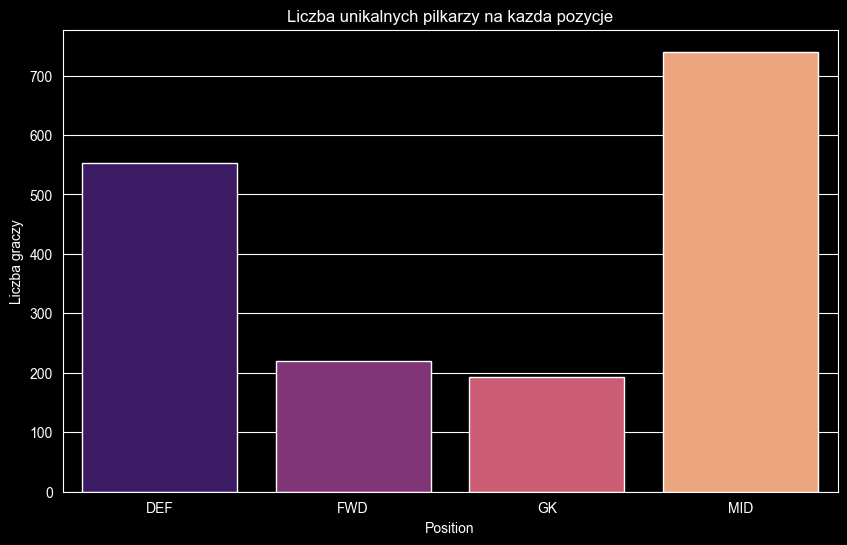

In [19]:
plt.figure(figsize=(10,6))
sns.barplot(data=data.groupby("position")["name"].nunique(), palette="magma", legend=False)
plt.title("Liczba unikalnych pilkarzy na kazda pozycje")
plt.xlabel("Position")
plt.ylabel("Liczba graczy")

In [20]:
[c for c in data.columns if "points" in c]

['total_points']

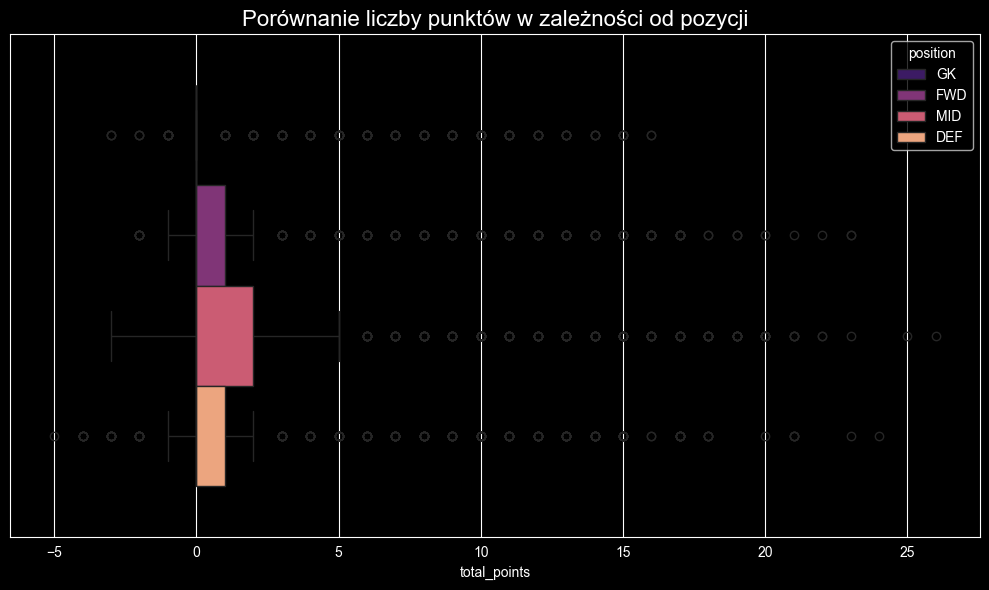

In [21]:
plt.figure(figsize=(10,  6))
sns.boxplot(data=data, x="total_points", hue="position", palette="magma")

plt.title("Porównanie liczby punktów w zależności od pozycji", fontsize=16)

plt.tight_layout()


Skośność: 3.110
Kurtoza:    11.820
Udział zer:          61.8%


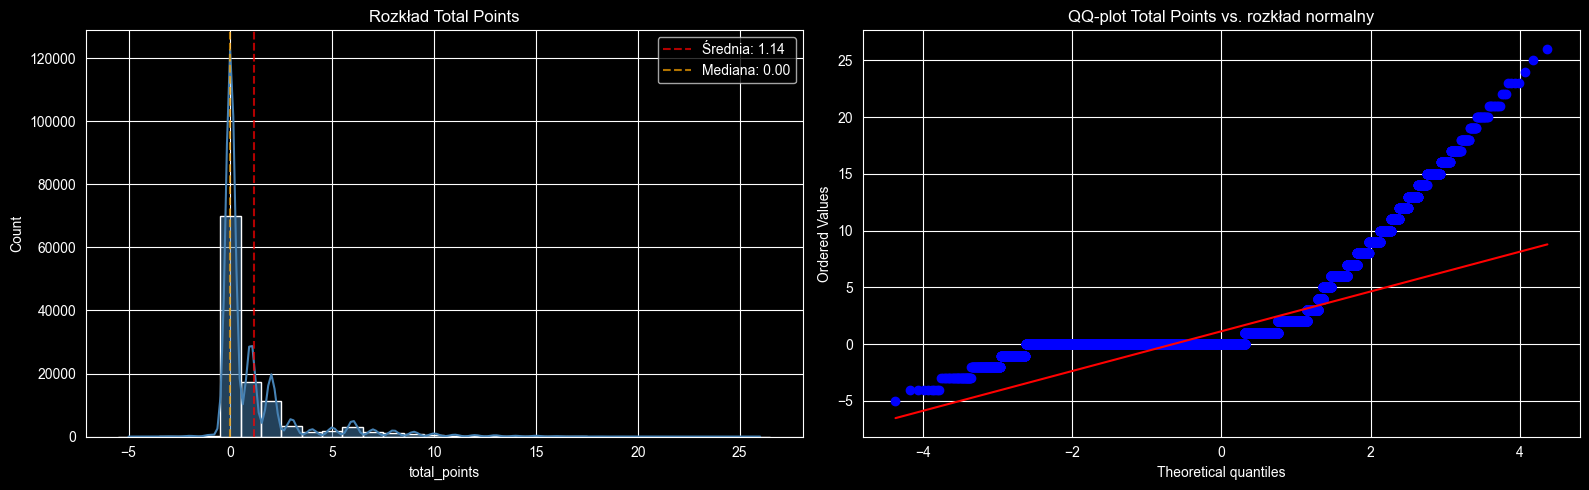

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
sns.histplot(data.total_points, kde=True, discrete=True, bins=30,
             color='steelblue', ax=ax)
ax.axvline(data.total_points.mean(), linestyle='--', color='r', alpha=0.7,
           label=f"Średnia: {data.total_points.mean():.2f}")
ax.axvline(data.total_points.median(), linestyle='--', color='orange', alpha=0.7,
           label=f"Mediana: {data.total_points.median():.2f}")
ax.legend(loc='upper right')
ax.set_title('Rozkład Total Points')

ax2 = axes[1]
stats.probplot(data.total_points, dist='norm', plot=ax2)
ax2.set_title('QQ-plot Total Points vs. rozkład normalny')

plt.tight_layout()

skew = float(data.total_points.skew())
kurt = float(data.total_points.kurtosis())
zero_pct = (data.total_points == 0).mean() * 100
print(f"Skośność: {skew:.3f}")
print(f"Kurtoza:    {kurt:.3f}")
print(f"Udział zer:          {zero_pct:.1f}%")

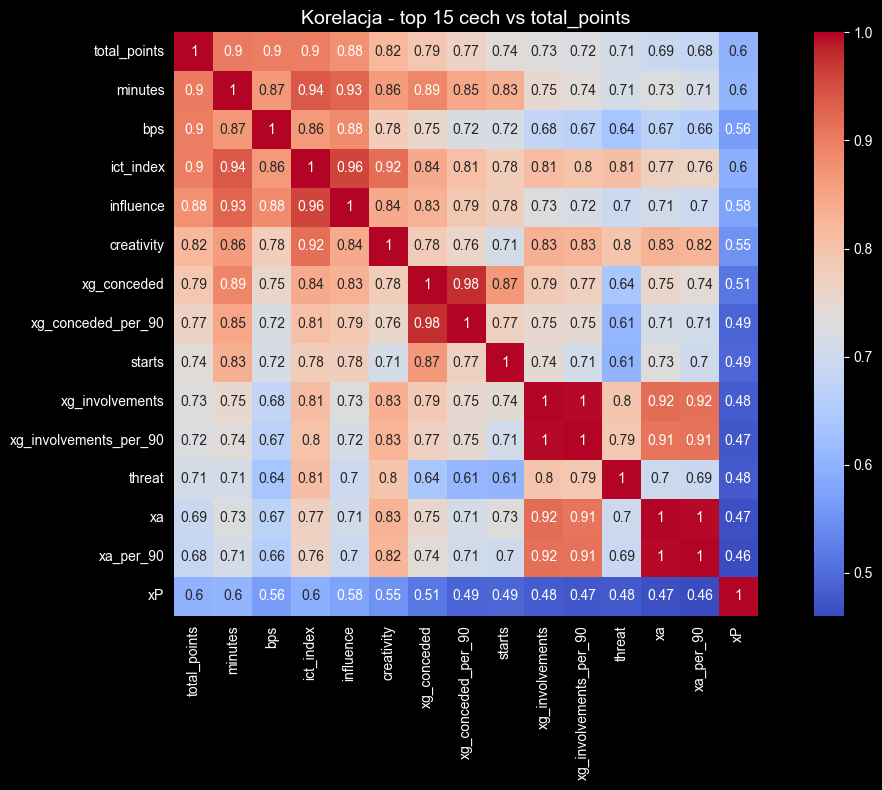

In [23]:
corr = data.select_dtypes(exclude=["object", "string"]).corr(method='spearman').apply(np.abs)
cols = corr["total_points"].sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 8))
sns.heatmap(corr.loc[cols, cols], annot=True, cmap="coolwarm", square=True)
plt.title("Korelacja - top 15 cech vs total_points", fontsize=14)
plt.tight_layout()

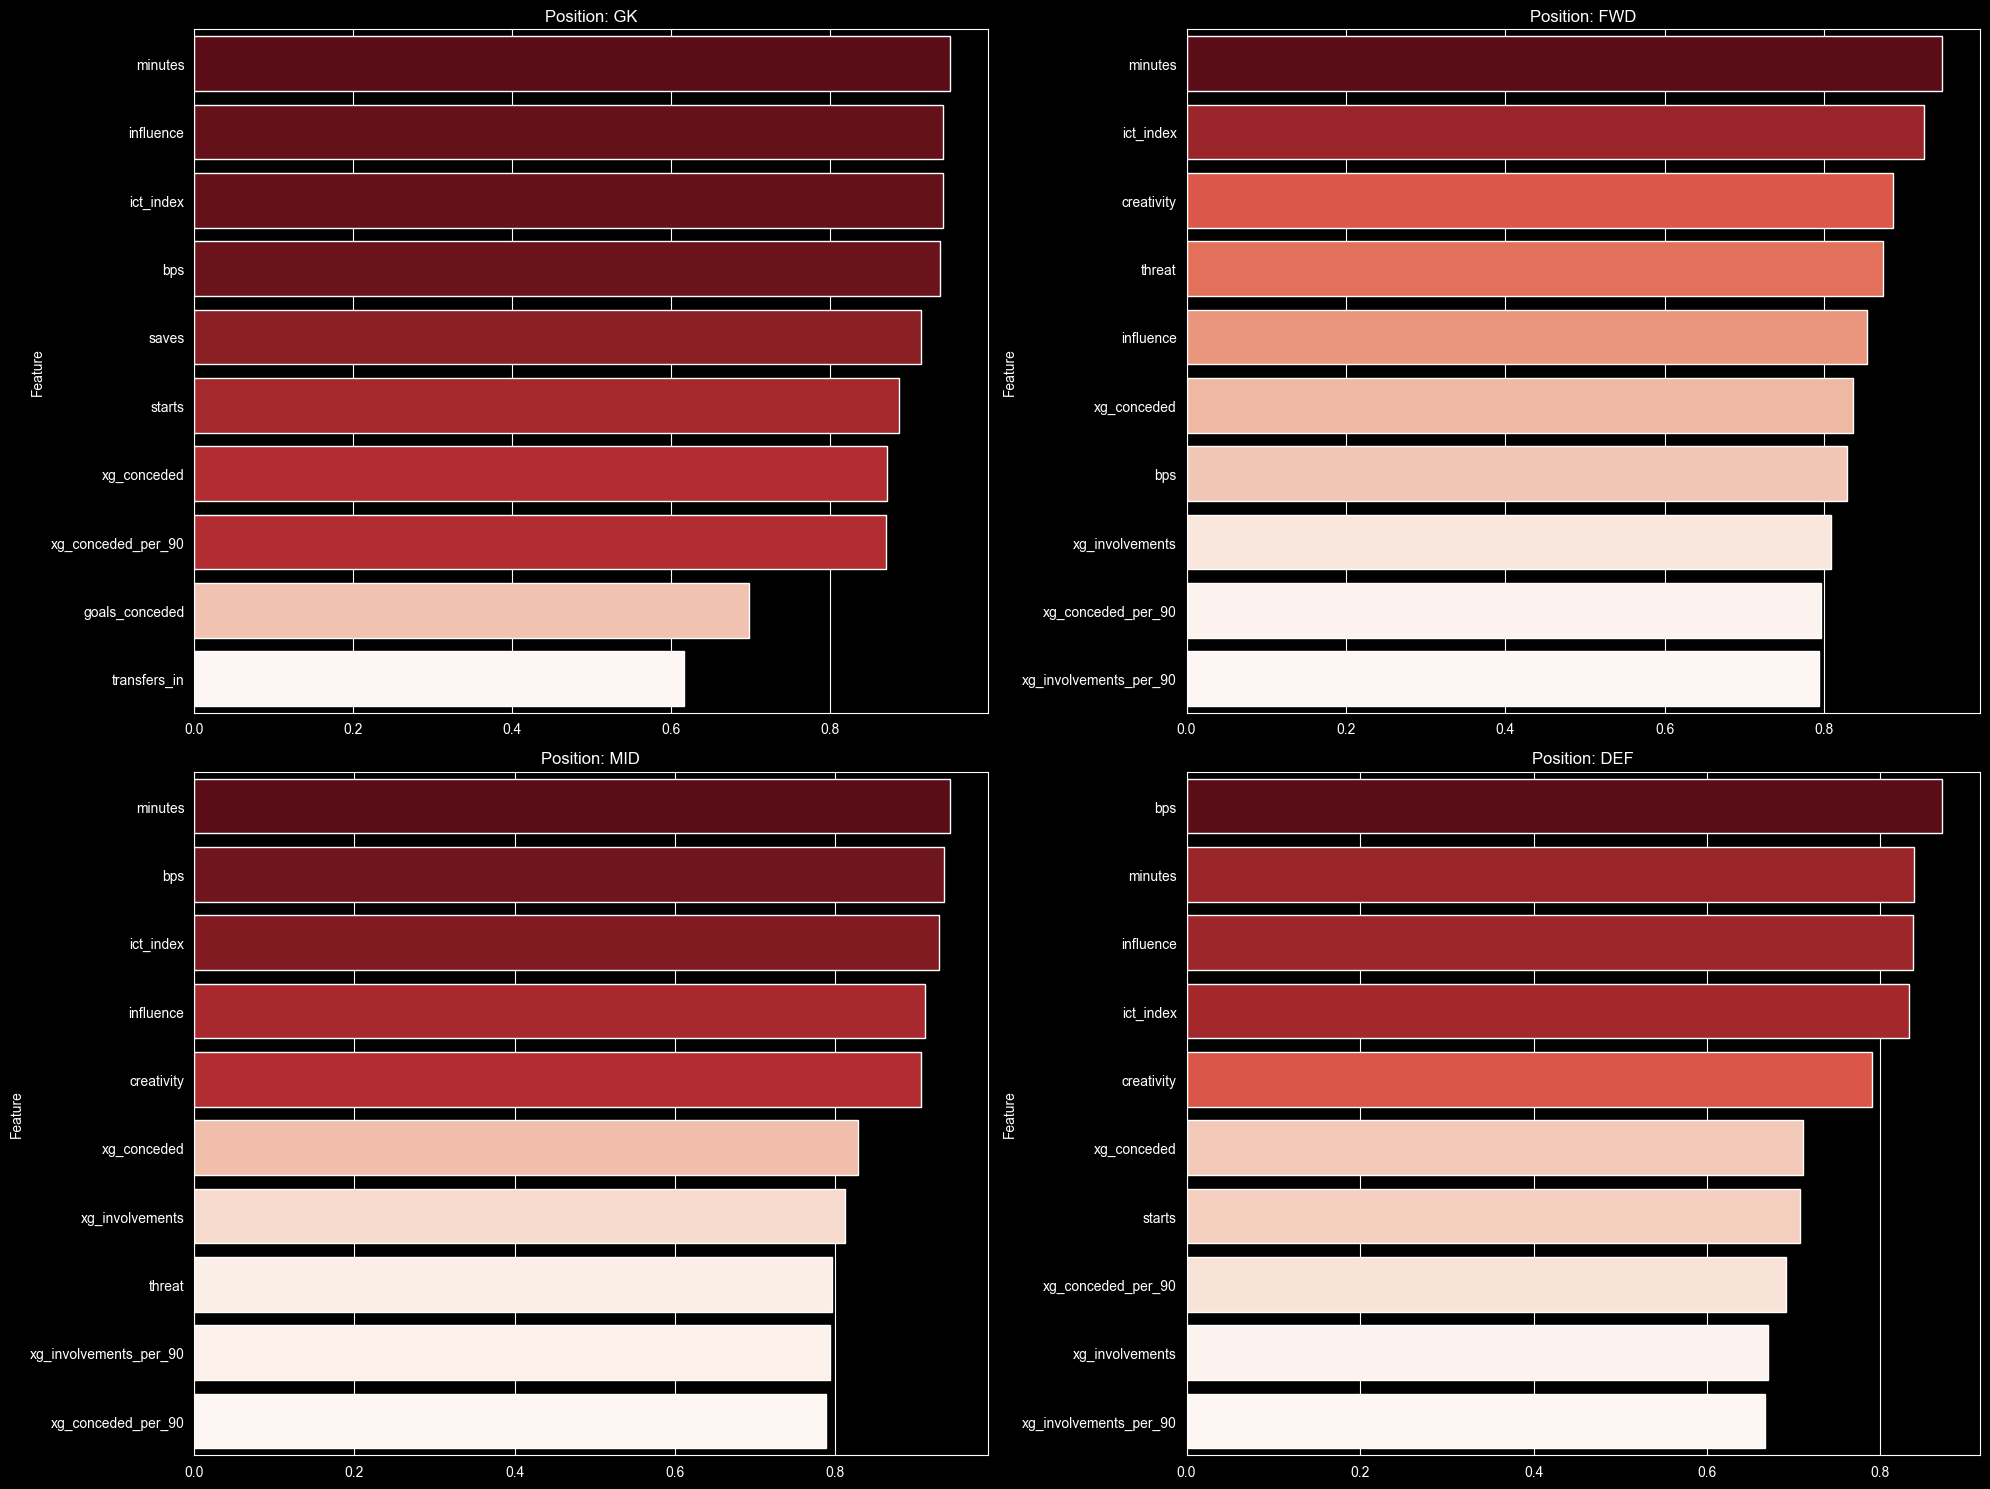

In [24]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 15)) 
axes_flat = axes.flatten()

for idx, position in enumerate(data.position.unique()):
    subset = data[data.position == position].select_dtypes(exclude=["object", "string"])
    corr = subset.corr("spearman").apply(np.abs)
    
    plot_data = corr["total_points"].sort_values(ascending=False).head(11).drop(["total_points"])
    
    sns.barplot(
        x=plot_data.values,
        y=plot_data.index,
        ax=axes_flat[idx],
        hue=plot_data.values,
        palette="Reds",
        legend=False
    )
    
    axes_flat[idx].set_title(f"Position: {position}")
    axes_flat[idx].set_ylabel("Feature")

plt.tight_layout()

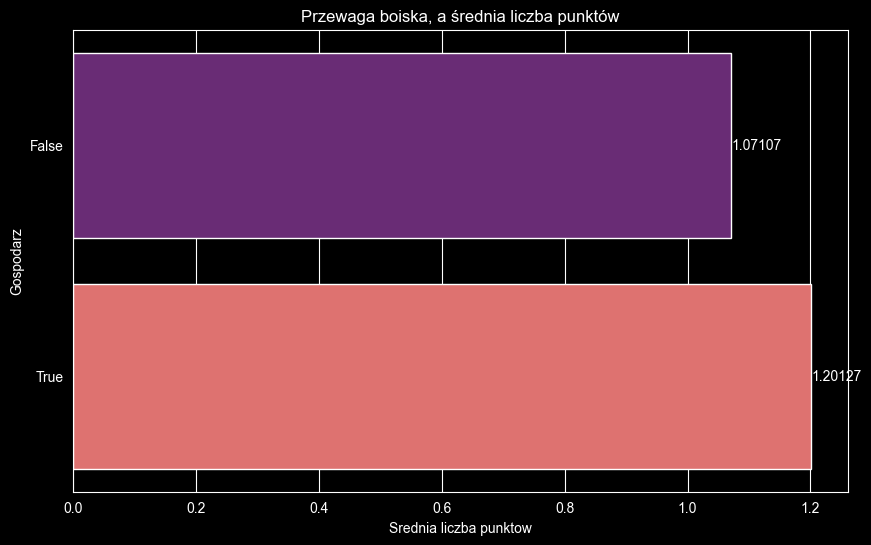

In [25]:
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=data,
    y="was_home",
    x="total_points",
    hue="was_home",
    estimator="mean",
    palette="magma",
    legend=False,
    errorbar=None,
    orient="h")

plt.xlabel("Srednia liczba punktow")
plt.ylabel("Gospodarz")

for container in ax.containers:
    ax.bar_label(container)
plt.title("Przewaga boiska, a średnia liczba punktów");

In [26]:
curr_gw = data[data.season==data.season.max()].gw.max()

In [27]:
"""fig = px.scatter(
    data[(data.season == data.season.max()) & (data.gw==curr_gw)],
    x="selected",
    y="total_points",
    color="position",
    facet_col="position",
    facet_col_wrap=2,
    hover_name="name", 
    hover_data={"selected": True, "total_points": True, "position": False},
    color_discrete_sequence=px.colors.sequential.Plasma,
    opacity=0.7,
    height=850,
    title="Punkty piłkarzy według pozycji i popularności"
)

fig.for_each_xaxis(lambda axis: axis.update(
    showticklabels=True, 
    tickformat=",d", 
    tickangle=0,
    showgrid=True,
    gridcolor='rgba(255, 255, 255, 0.1)',
    
))

fig.for_each_yaxis(lambda axis: axis.update(
    showticklabels=True, 
    tickformat=",d",
    showgrid=True,
    gridcolor='rgba(255, 255, 255, 0.1)',
    title_text="Suma punktów"
))

fig.update_layout(
    showlegend=False,
    template="plotly_dark",
    font=dict(
        family="Arial, sans-serif",
        size=12,
        color="#FFFFFF"
    ),    
    )


for annotation in fig["layout"]["annotations"]:
    annotation['font'] = dict(size=14, color="#FFFFFF", family="Arial Black")
    annotation['text'] = annotation['text'].split("=")[-1].upper()

fig.show(renderer="notebook")"""

'fig = px.scatter(\n    data[(data.season == data.season.max()) & (data.gw==curr_gw)],\n    x="selected",\n    y="total_points",\n    color="position",\n    facet_col="position",\n    facet_col_wrap=2,\n    hover_name="name", \n    hover_data={"selected": True, "total_points": True, "position": False},\n    color_discrete_sequence=px.colors.sequential.Plasma,\n    opacity=0.7,\n    height=850,\n    title="Punkty piłkarzy według pozycji i popularności"\n)\n\nfig.for_each_xaxis(lambda axis: axis.update(\n    showticklabels=True, \n    tickformat=",d", \n    tickangle=0,\n    showgrid=True,\n    gridcolor=\'rgba(255, 255, 255, 0.1)\',\n\n))\n\nfig.for_each_yaxis(lambda axis: axis.update(\n    showticklabels=True, \n    tickformat=",d",\n    showgrid=True,\n    gridcolor=\'rgba(255, 255, 255, 0.1)\',\n    title_text="Suma punktów"\n))\n\nfig.update_layout(\n    showlegend=False,\n    template="plotly_dark",\n    font=dict(\n        family="Arial, sans-serif",\n        size=12,\n        col

In [28]:
data[(data.season==data.season.max()) & (data.gw==curr_gw)].loc[
    (data.selected < data.selected.quantile(.5)) &
    (data.total_points > data.total_points.quantile(.9)) &
    (data.minutes > 0),
["name", "position", "selected", "total_points", "xP", "gw", "minutes"]].sort_values(by=["position", "total_points"], ascending=False)

,name,position,selected,total_points,xP,gw,minutes
43827,Curtis Jones,MID,0.000076,10.0,4.3,38.0,90.0
7686,Tom Cairney,MID,0.000022,6.0,2.2,38.0,30.0
11739,Ross Barkley,MID,0.000057,5.0,3.5,38.0,85.0
48962,Leon Bailey,MID,0.000071,5.0,1.3,38.0,90.0
82166,Loum Tchaouna,MID,0.000030,5.0,4.2,38.0,74.0
94288,Omari Hutchinson,MID,0.000050,5.0,2.2,38.0,77.0
24698,Jefferson Lerma Solís,MID,0.000060,4.0,0.4,38.0,90.0
46143,Ibrahim Sangaré,MID,0.000042,4.0,1.2,38.0,64.0
49187,Florentino Ibrain Morris Luís,MID,0.000030,4.0,3.2,38.0,90.0
81021,Nico González Iglesias,MID,0.000070,4.0,1.7,38.0,90.0


In [29]:
team_x_stats = [c for c in data.columns if "x" in c and c!="ict_index" and ("team" in c or "opp" in c)]
player_x_stasts = [c for c in data.columns if "x" in c and c!="ict_index" and c not in team_x_stats and c !="xP"]

player_x_stasts

['xa',
 'xg_involvements',
 'xg',
 'xg_conceded',
 'fixture',
 'xa_per_90',
 'xg_involvements_per_90',
 'xg_per_90',
 'xg_conceded_per_90']

In [30]:
data.position.unique()

array(['GK', 'FWD', 'MID', 'DEF'], dtype=object)

In [31]:
"""radar_plot_x_stats(df=data,
                   players=["Erling Haaland", "Antoine Semenyo", "Mohamed Salah", "Bruno Fernandes"],
                   stats=player_x_stasts)"""

'radar_plot_x_stats(df=data,\n                   players=["Erling Haaland", "Antoine Semenyo", "Mohamed Salah", "Bruno Fernandes"],\n                   stats=player_x_stasts)'

In [32]:
"""radar_plot_x_stats(df=data,
                   players=['Kenny Tete', "Marc Guéhi", "Lewis Hall",  'Trevoh Chalobah'],
                   stats=player_x_stasts)"""

'radar_plot_x_stats(df=data,\n                   players=[\'Kenny Tete\', "Marc Guéhi", "Lewis Hall",  \'Trevoh Chalobah\'],\n                   stats=player_x_stasts)'

In [33]:
pca_pipe = Pipeline([
    ("scale", RobustScaler()),
    ("pca", PCA())
])

"""umap_pipe = Pipeline([
    ("scale", RobustScaler()),
    ("umap", umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.001, random_state=77))
])"""

'umap_pipe = Pipeline([\n    ("scale", RobustScaler()),\n    ("umap", umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.001, random_state=77))\n])'

In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [35]:
X = data.select_dtypes(exclude="object").drop(columns=["gw", "round", "code", "element", "season", "fixture", "kickoff_time", "date"])


In [36]:
X

,xP,assists,bonus,bps,clean_sheets,creativity,xa,xg_involvements,xg,xg_conceded,goals_conceded,goals_scored,ict_index,influence,minutes,own_goals,penalties_missed,penalties_saved,red_cards,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,yellow_cards,was_home,prob_win,prob_draw,prob_lose,prob_over_2.5,prob_under_2.5,elo,xa_per_90,xg_involvements_per_90,xg_per_90,xg_conceded_per_90
0,1.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,False,0.250399,0.295085,0.454516,0.406091,0.593909,1668.829956,0.0,0.0,0.0,0.0
1,-0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.932986e-07,0.0,4.0,1.0,0.0,0.0,17.0,18.0,1.0,4.0,0.0,True,0.198312,0.259413,0.542276,0.467363,0.532637,1672.510376,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.452826e-07,0.0,2.0,2.0,0.0,0.0,19.0,25.0,6.0,4.0,0.0,False,0.252755,0.277665,0.469580,0.471204,0.528796,1664.741699,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.484797e-07,0.0,5.0,1.0,0.0,0.0,11.0,32.0,21.0,4.0,0.0,False,0.112712,0.180126,0.707162,0.599496,0.400504,1667.643433,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.562414e-07,0.0,3.0,0.0,0.0,0.0,-3.0,22.0,25.0,4.0,0.0,True,0.108515,0.184539,0.706946,0.580563,0.419437,1694.991699,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113265,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.462000e-06,0.0,1.0,1.0,0.0,0.0,2.0,16.0,14.0,4.5,0.0,True,0.395840,0.266909,0.337250,0.547619,0.452381,1666.313843,0.0,0.0,0.0,0.0
113266,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,False,0.339537,0.251239,0.409224,0.637037,0.362963,1933.218750,0.0,0.0,0.0,0.0
113267,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.343957e-07,0.0,1.0,1.0,0.0,0.0,90.0,97.0,7.0,4.0,0.0,True,0.515876,0.237695,0.246429,0.665083,0.334917,1926.309448,0.0,0.0,0.0,0.0
113268,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.420230e-06,0.0,2.0,4.0,0.0,0.0,49.0,77.0,28.0,4.0,0.0,False,0.386574,0.273074,0.340353,0.559055,0.440945,1922.572632,0.0,0.0,0.0,0.0


In [37]:
X = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

In [38]:
pca1 = pca_pipe.fit_transform(X)


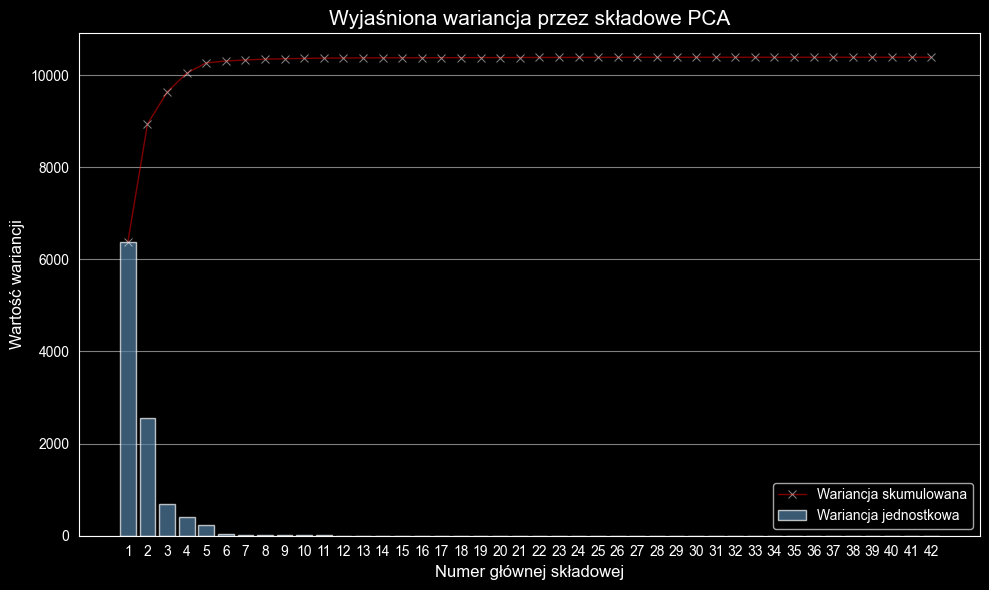

In [39]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=list(range(1, len(pca_pipe.named_steps["pca"].explained_variance_) + 1)), y=pca_pipe.named_steps["pca"].explained_variance_, color="steelblue", alpha=0.7, label="Wariancja jednostkowa")

sns.lineplot(x=range(len(range(1, len(pca_pipe.named_steps["pca"].explained_variance_) + 1))), y=np.cumsum(pca_pipe.named_steps["pca"].explained_variance_), color="red", marker="x", linewidth=1, alpha=.5, label="Wariancja skumulowana")

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title("Wyjaśniona wariancja przez składowe PCA", fontsize=15)
plt.xlabel("Numer głównej składowej", fontsize=12)
plt.ylabel("Wartość wariancji", fontsize=12)
plt.legend()

plt.grid(axis="y", alpha=.5)
plt.tight_layout()

In [40]:
pca_pipe = Pipeline([
    ("scale", RobustScaler()),
    ("pca", PCA(2))
])

pca2 = pca_pipe.fit_transform(X)


Text(0.5, 1.0, 'Wpływ cech na główne składowe (Loadings)')

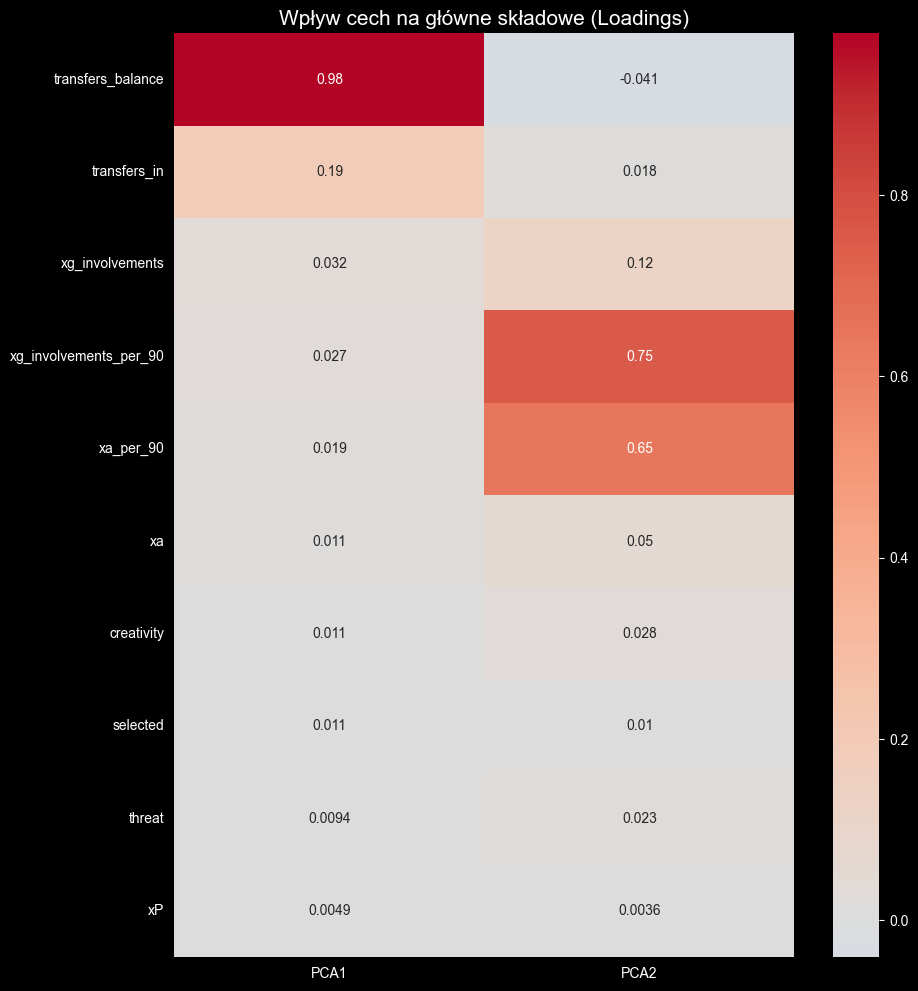

In [41]:
loadings = pd.DataFrame(
    pca_pipe.named_steps["pca"].components_[:2].T, 
    columns=['PCA1', 'PCA2'], 
    index=X.columns
)

plt.figure(figsize=(10, 12))
sns.heatmap(loadings.sort_values(by=["PCA1", "PCA2"], ascending=False).head(10), 
            annot=True, cmap='coolwarm', center=0)

plt.title("Wpływ cech na główne składowe (Loadings)", fontsize=15)

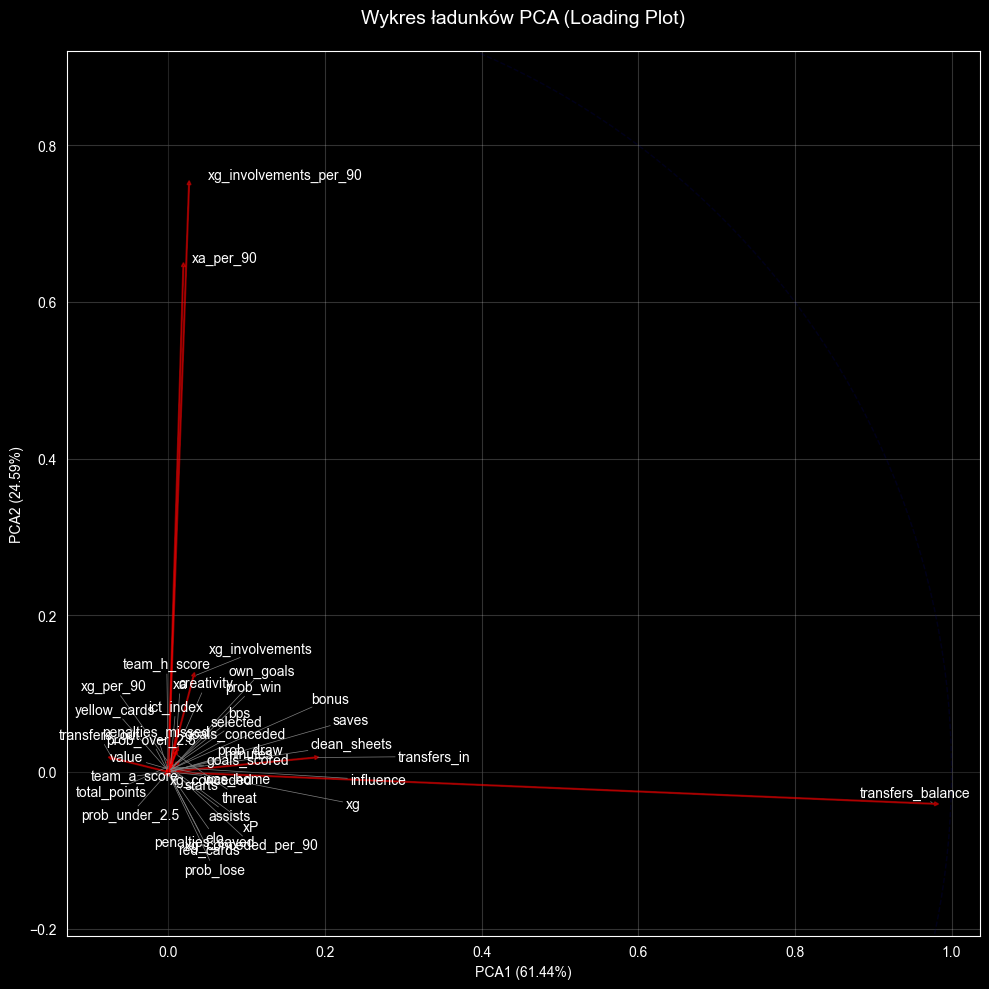

In [42]:
def plot_pca_loadings(loadings, pca_obj):
    plt.figure(figsize=(10, 10))
    
    texts = []
    for i, feature in enumerate(loadings.index):
        x = loadings.iloc[i, 0]
        y = loadings.iloc[i, 1]
        
        plt.arrow(0, 0, x, y, color='red', alpha=0.5, head_width=0.005, head_length=0.005)
        
        texts.append(plt.text(x, y, feature, fontsize=10, fontweight='medium'))

    circle = plt.Circle((0,0), 1, color='navy', fill=False, linestyle='--', alpha=0.2)
    plt.gca().add_artist(circle)

    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.axis('equal')
    
    plt.axhline(0, color='black', linewidth=0.8, alpha=0.3)
    plt.axvline(0, color='black', linewidth=0.8, alpha=0.3)
    
    plt.xlabel(f'PCA1 ({pca_obj.explained_variance_ratio_[0]:.2%})')
    plt.ylabel(f'PCA2 ({pca_obj.explained_variance_ratio_[1]:.2%})')
    
    plt.title('Wykres ładunków PCA (Loading Plot)', fontsize=14, pad=20)
    plt.grid(alpha=0.2)

    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    plt.tight_layout()
    plt.show()

plot_pca_loadings(loadings, pca_pipe.named_steps["pca"])

In [43]:
def cluster_and_test(data, k_map, season, test_features=None, num_drop=None):

    if test_features is None:
        test_features = ['total_points', 'minutes', 'xg_per_90', 'xa_per_90',
                         'xg_conceded_per_90', 'team_xp', 'opp_xp']
    if num_drop is None:
        num_drop = ['gw', 'round', 'code', 'element', 'season', 'id',
                    'total_points', 'minutes']

    df = data[data.season == season].copy()
    if df.empty:
        raise ValueError(f"Brak danych dla sezonu: {season}. "
                         f"Dostępne sezony: {data.season.unique()}")

    num_cols = df.select_dtypes('number').columns.drop(num_drop, errors='ignore')

    positions = [p for p in df.position.unique() if p in k_map]
    n_pos = len(positions)
    fig, axes = plt.subplots(
        (n_pos + 1) // 2, 2, figsize=(15, 6 * ((n_pos + 1) // 2))
    )
    axes = np.array(axes).flatten()
    cluster_results = {}

    for ax, pos in zip(axes, positions):
        d = df[df.position == pos].copy().reset_index(drop=True)
        X = RobustScaler().fit_transform(d[num_cols].fillna(0))
        k = k_map.get(pos, 3)

        d['cluster'] = KMeans(k, n_init=10, random_state=42).fit_predict(X)
        pca_coords = PCA(2).fit_transform(X)
        d['pca_x'], d['pca_y'] = pca_coords[:, 0], pca_coords[:, 1]

        d_plot = d.groupby(['name', 'cluster'], as_index=False)[['pca_x', 'pca_y']].mean()

        sns.scatterplot(data=d_plot, x='pca_x', y='pca_y', hue='cluster',
                        ax=ax, palette='viridis', s=50)
        txts = [ax.text(r.pca_x, r.pca_y, r['name'], fontsize=7)
                for c in range(k)
                for _, r in d_plot[d_plot.cluster == c].head(5).iterrows()]
        adjust_text(txts, ax=ax, arrowprops=dict(arrowstyle='->', color='red', lw=0.5))
        ax.set_title(f"{pos}  (k={k})")
        cluster_results[pos] = d

    for ax in axes[len(positions):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

    # ── Kruskal-Wallis + Bonferroni ───────────────────────────────────────────
    rows = []
    for pos, d in cluster_results.items():
        feats = [f for f in test_features if f in d.columns]
        if not feats:
            continue

        pvals, hstats = [], []
        for feat in feats:
            groups = [d[d.cluster == c][feat].dropna().values for c in d.cluster.unique()]
            try:
                h, p = kruskal(*groups)
            except Exception:
                h, p = np.nan, 1.0
            hstats.append(h)
            pvals.append(p)

        reject, p_corr, _, _ = multipletests(pvals, method='bonferroni')
        n, k_pos = len(d), d.cluster.nunique()
        eta2 = [(h - k_pos + 1) / (n - k_pos) if not np.isnan(h) else np.nan
                for h in hstats]

        for feat, h, p, pc, sig, e2 in zip(feats, hstats, pvals, p_corr, reject, eta2):
            rows.append(dict(position=pos, feature=feat,
                             H_stat=round(h, 3) if not np.isnan(h) else np.nan,
                             p_bonferroni=round(pc, 4), significant=sig,
                             eta_squared=round(e2, 4) if not np.isnan(e2) else np.nan))

    if not rows:
        raise RuntimeError("Brak wyników Kruskala – sprawdź test_features i dane.")

    # ── Heatmapa ──────────────────────────────────────────────────────────────
    summary = pd.DataFrame(rows)
    pivot_eta = summary.pivot_table(index='feature', columns='position',
                                    values='eta_squared', aggfunc='first')
    pivot_sig = summary.pivot_table(index='feature', columns='position',
                                    values='significant', aggfunc='first')

    plt.figure(figsize=(10, 6))
    ax = sns.heatmap(pivot_eta, annot=True, fmt='.3f', cmap='YlOrRd',
                     linewidths=0.5, cbar_kws={'label': 'Eta²'})
    for i, feat in enumerate(pivot_eta.index):
        for j, pos in enumerate(pivot_eta.columns):
            val = pivot_sig.loc[feat, pos]
            if pd.notna(val) and val:
                ax.text(j + 0.85, i + 0.25, '*', fontsize=14,
                        color='navy', fontweight='bold')

    plt.title(f'Eta² per pozycja | sezon: {season} | * = istotne po Bonferronim')
    plt.tight_layout()
    plt.show()
    print("Eta² ≈ 0.01 mały | 0.06 średni | 0.14+ duży efekt")

    return summary, cluster_results

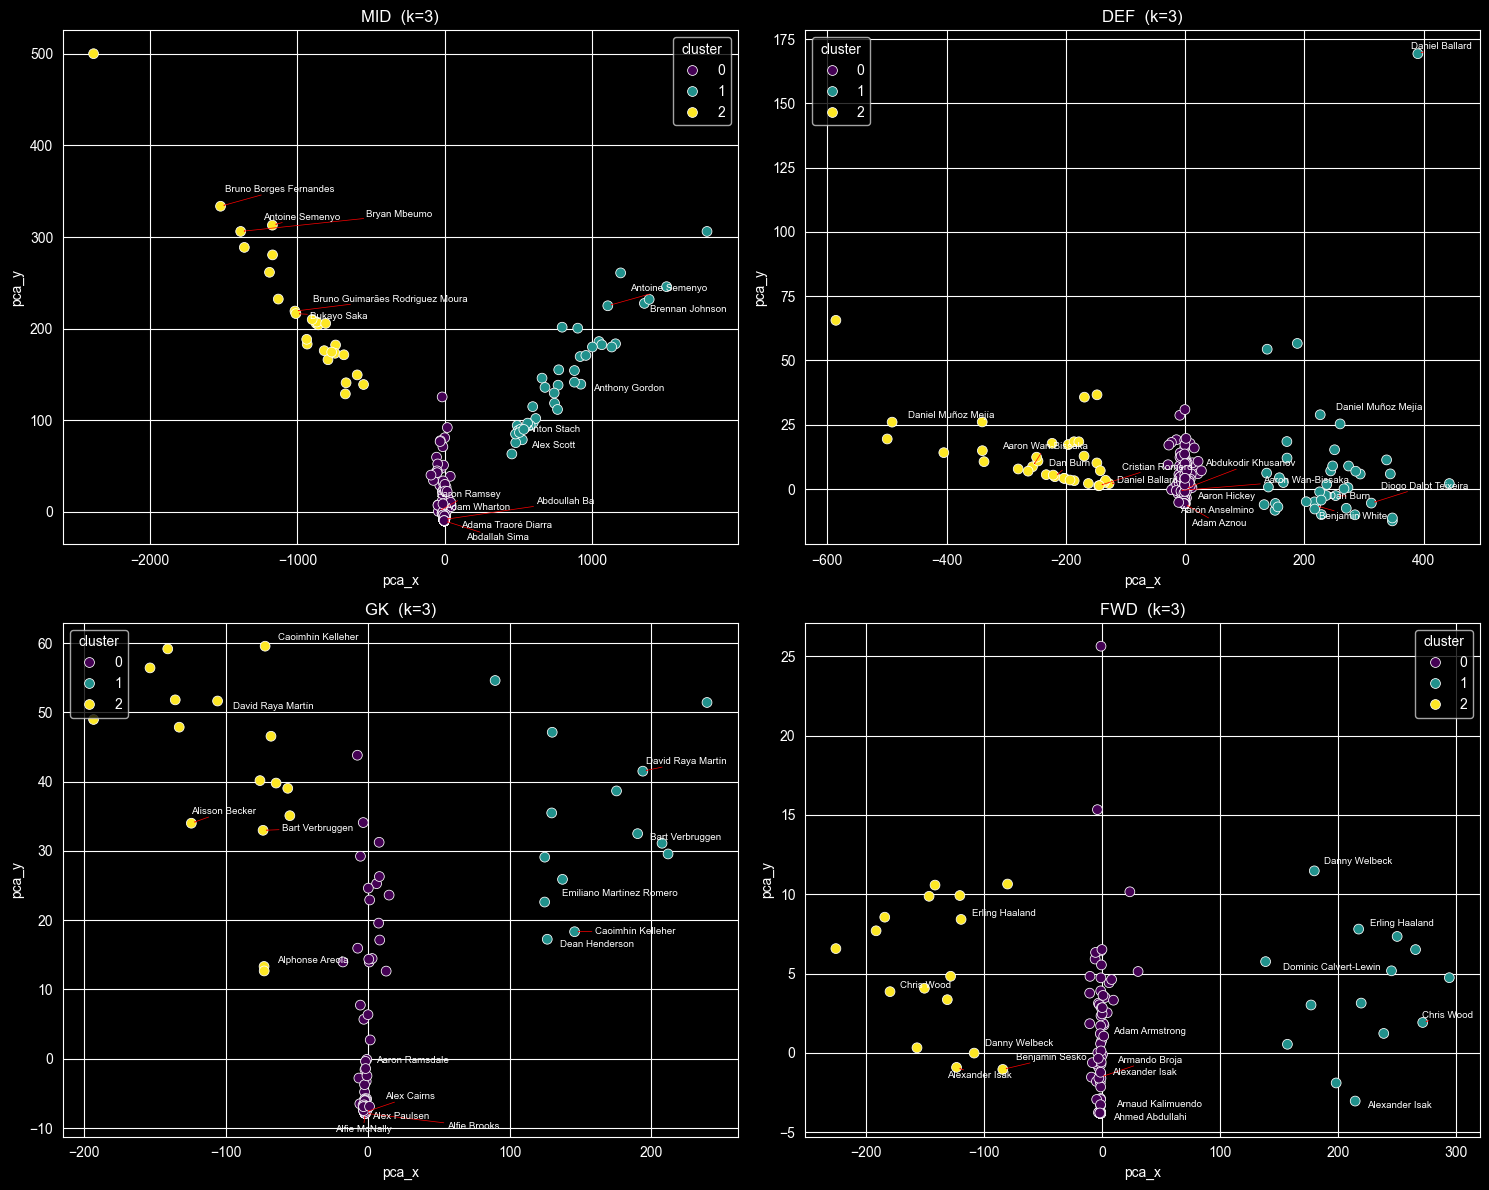

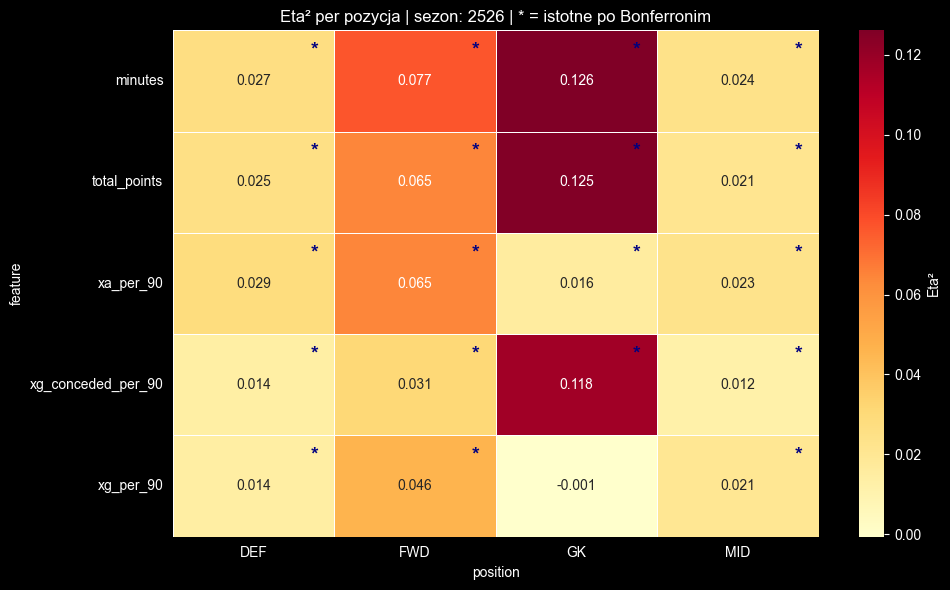

Eta² ≈ 0.01 mały | 0.06 średni | 0.14+ duży efekt


In [44]:
summary, clusters = cluster_and_test(data=data, k_map={'FWD': 3, 'MID': 3, 'DEF': 3, 'GK': 3}, season=2526)

In [45]:
data.to_parquet(config.TIDY_DATA_PATH)